# ============================================================
# FLOWER CLASSIFICATION RESEARCH PROJECT
# Dataset: 5-Class Flowers (daisy, dandelion, roses,
#          sunflowers, tulips)
# Models: Linear NN → Hidden Layer NN → Improved NN
#         → EfficientNetB0 Transfer Learning → AlexNet
#         → VGG16 → ResNet50
# ============================================================

In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║         SECTION 0 — INSTALL & IMPORTS                   ║
# ╚══════════════════════════════════════════════════════════╝

!pip install tensorflow wandb seaborn scikit-learn --quiet
!unzip -q archive.zip   # your flowers dataset zip

import os
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import wandb
from wandb.integration.keras import WandbMetricsLogger

# ── Reproducibility ──────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

# ── Global Constants ──────────────────────────────────────
TRAIN_DIR       = "/content/train"
IMG_CHANNELS    = 3
BATCH_SIZE      = 32
AUTOTUNE        = tf.data.AUTOTUNE

# 64x64 → for Dense/Flat models (avoids OOM from huge flatten)
# 224×224 flatten = 150,528 neurons → ~77M params in first layer → GPU OOM
# 64×64  flatten = 12,288  neurons → ~3M  params → fits safely in GPU RAM
IMG_HEIGHT_SMALL = 64
IMG_WIDTH_SMALL  = 64

# 224x224 → for CNN / Transfer Learning models (convolutions handle this fine)
IMG_HEIGHT = 224
IMG_WIDTH  = 224


Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.
Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.
Classes (5): ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


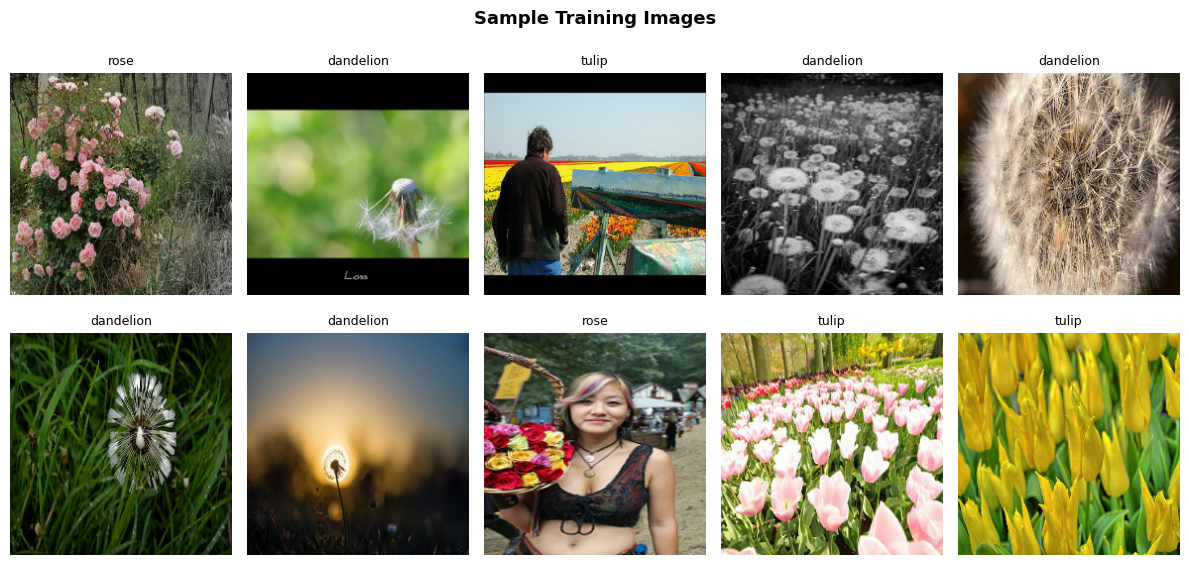

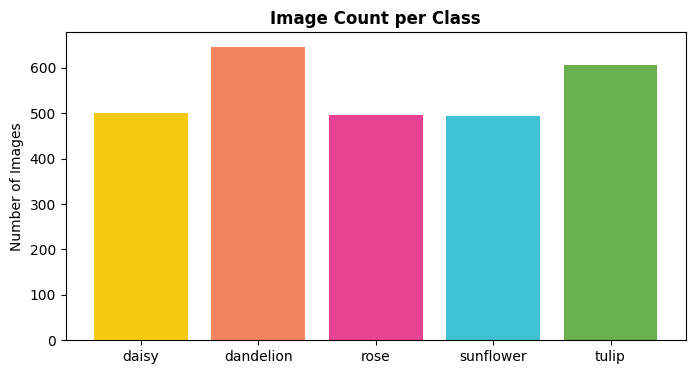

In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║         SECTION 1 — DATA LOADING & EXPLORATION          ║
# ╚══════════════════════════════════════════════════════════╝

# ── Large images (224x224) for CNN models ─────────────────
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training",
    seed=42, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation",
    seed=42, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
)

# ── Small images (64x64) for Dense/Flat models ────────────
train_dataset_small = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training",
    seed=42, image_size=(IMG_HEIGHT_SMALL, IMG_WIDTH_SMALL), batch_size=BATCH_SIZE
)
val_dataset_small = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation",
    seed=42, image_size=(IMG_HEIGHT_SMALL, IMG_WIDTH_SMALL), batch_size=BATCH_SIZE
)

CLASS_NAMES = train_dataset.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

# ── Visualise sample images ───────────────────────────────
plt.figure(figsize=(12, 6))
for images, labels in train_dataset.take(1):
    for i in range(min(10, BATCH_SIZE)):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[labels[i]], fontsize=9)
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Count images per class ────────────────────────────────
class_counts = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    class_counts[cls] = len(os.listdir(cls_path))

plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values(),
        color=["#f6c90e","#f4845f","#e84393","#3ec1d3","#6ab04c"])
plt.title("Image Count per Class", fontweight="bold")
plt.ylabel("Number of Images")
plt.show()

# ── Normalize helper ──────────────────────────────────────
def normalize_and_prefetch(ds):
    norm = layers.Rescaling(1./255)
    ds = ds.map(lambda x, y: (norm(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

# ── Build all pipelines ───────────────────────────────────
train_ds       = normalize_and_prefetch(train_dataset)        # 224x224 normalised
val_ds         = normalize_and_prefetch(val_dataset)          # 224x224 normalised
train_ds_small = normalize_and_prefetch(train_dataset_small)  # 64x64  normalised
val_ds_small   = normalize_and_prefetch(val_dataset_small)    # 64x64  normalised
train_ds_raw   = train_dataset.prefetch(AUTOTUNE)             # 224x224 raw [0-255]
val_ds_raw     = val_dataset.prefetch(AUTOTUNE)               # 224x224 raw [0-255]


# ╔══════════════════════════════════════════════════════════╗
# ║   SHARED HELPERS  (evaluation + plotting)               ║
# ╚══════════════════════════════════════════════════════════╝

def evaluate_model(model, val_ds, class_names, title="Model"):
    """Print classification report and plot confusion matrix."""
    y_true, y_pred = [], []
    for images, labels in val_ds:
        preds = np.argmax(model.predict(images, verbose=0), axis=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{title} — Confusion Matrix", fontweight="bold")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()

    cr = classification_report(y_true, y_pred, target_names=class_names)
    print(f"\n{title} — Classification Report:\n{cr}")
    return y_true, y_pred


def plot_history(history, title="Model"):
    """Plot training/validation loss and accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"],     label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title} — Loss"); axes[0].legend()

    axes[1].plot(history.history["accuracy"],     label="Train Acc")
    axes[1].plot(history.history["val_accuracy"], label="Val Acc")
    axes[1].set_title(f"{title} — Accuracy"); axes[1].legend()

    plt.tight_layout(); plt.show()


def merge_histories(h1, h2):
    """Merge two Keras history objects for two-phase training plots."""
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    class FakeHistory:
        pass
    fh = FakeHistory()
    fh.history = merged
    return fh


# Dictionary to store final val accuracy for comparison table
RESULTS = {}


Model: "Linear_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │        61,445 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,445 (240.02 KB)

 Trainable params: 61,445 (240.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.3364 - loss: 1.9176 - val_accuracy: 0.3916 - val_loss: 1.3950
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.4406 - loss: 1.3853 - val_accuracy: 0.3843 - val_loss: 1.5567
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.4734 - loss: 1.4398 - val_accuracy: 0.3698 - val_loss: 1.6601
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.4975 - loss: 1.3758 - val_accuracy: 0.4463 - val_loss: 1.4355
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.5357 - loss: 1.2253 - val_accuracy: 0.3971 - val_loss: 1.4972
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5635 - loss: 1.1485 - val_accuracy: 0.4645 - val_loss: 1.4559
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5699 - loss: 1.1569 - val_accuracy: 0.3734 - val_loss: 1.7946
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6231 - loss: 0.9742 - val_accuracy: 0.3716 - v

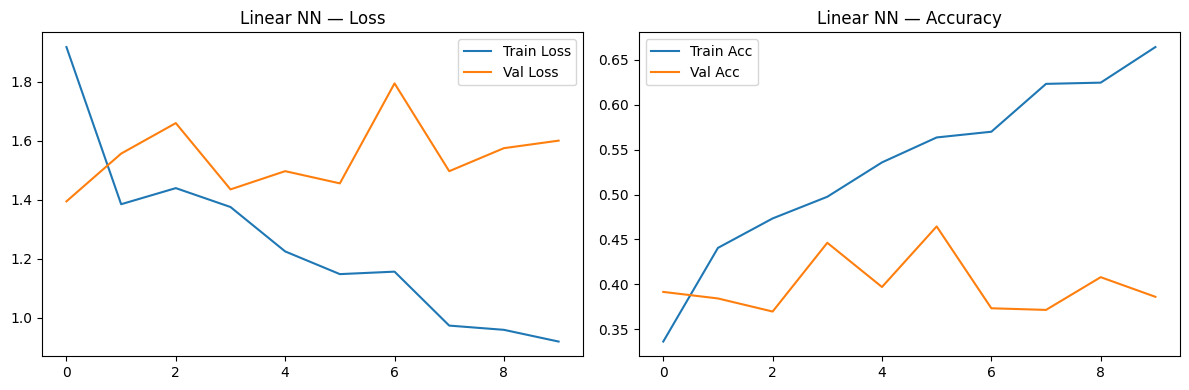

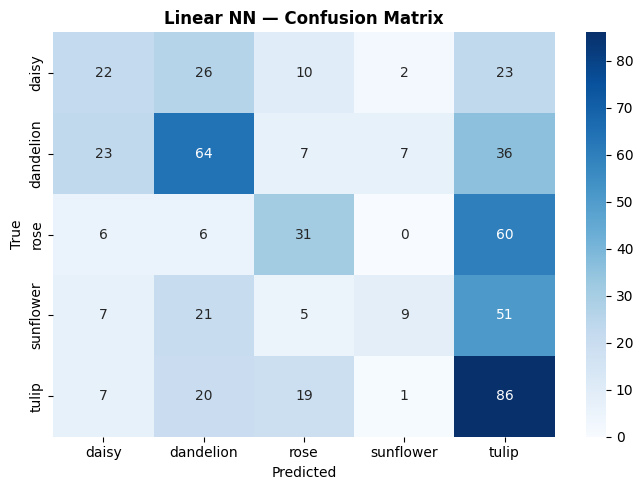


Linear NN — Classification Report:
              precision    recall  f1-score   support

       daisy       0.34      0.27      0.30        83
   dandelion       0.47      0.47      0.47       137
        rose       0.43      0.30      0.35       103
   sunflower       0.47      0.10      0.16        93
       tulip       0.34      0.65      0.44       133

    accuracy                           0.39       549
   macro avg       0.41      0.36      0.34       549
weighted avg       0.41      0.39      0.36       549



In [3]:
# ╔══════════════════════════════════════════════════════════╗
# ║   MODEL 1 — LINEAR NEURAL NETWORK (BASELINE)            ║
# ║   Input: 64x64  |  No hidden layers                     ║
# ╚══════════════════════════════════════════════════════════╝
"""
A linear/logistic classifier: pixels are flattened into a single
vector, then passed directly to a softmax output layer.
No hidden layers → purely linear decision boundaries.
Uses 64x64 images to keep flatten output at 12,288 neurons
(vs 150,528 at 224x224 which causes GPU OOM).
This is our weakest baseline and sets the floor for comparison.
"""

linear_model = keras.Sequential([
    keras.Input(shape=(IMG_HEIGHT_SMALL, IMG_WIDTH_SMALL, IMG_CHANNELS)),
    layers.Flatten(),                               # 64x64x3 = 12,288
    layers.Dense(NUM_CLASSES, activation="softmax")
], name="Linear_NN")

linear_model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
linear_model.summary()

history_linear = linear_model.fit(
    train_ds_small, validation_data=val_ds_small, epochs=10, verbose=1
)
plot_history(history_linear, "Linear NN")
evaluate_model(linear_model, val_ds_small, CLASS_NAMES, "Linear NN")

RESULTS["1. Linear NN"] = max(history_linear.history["val_accuracy"])


# ╔══════════════════════════════════════════════════════════╗

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: aaa2633522 (aaa2633522-bahria-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Model: "Hidden_Layer_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,181,061 (12.13 MB)

 Trainable params: 3,180,293 (12.13 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.3373 - loss: 1.8055 - val_accuracy: 0.3443 - val_loss: 1.9729
Epoch 2/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.4165 - loss: 1.4880 - val_accuracy: 0.3734 - val_loss: 1.5774
Epoch 3/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.4538 - loss: 1.4175 - val_accuracy: 0.4681 - val_loss: 1.2348
Epoch 4/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.4752 - loss: 1.3349 - val_accuracy: 0.4827 - val_loss: 1.2256
Epoch 5/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.4975 - loss: 1.2674 - val_accuracy: 0.4189 - val_loss: 1.3506
Epoch 6/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5075 - loss: 1.2358 - val_accuracy: 0.4590 - val_loss: 1.3453
Epoch 7/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5180 - loss: 1.2056 - val_accuracy: 0.3643 - val_loss: 1.4855
Epoch 8/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5289 - loss: 1.1481 - val_accuracy: 0.4098 -

epoch/accuracy,▁▃▄▅▅▆▆▆▇▇██▇██
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▄▄▃▃▃▂▂▂▁▁▂▁▁
epoch/val_accuracy,▃▄▇█▆▇▄▅▅▂▂█▁▄▃
epoch/val_loss,█▄▁▁▂▂▃▃▃▅▆▁▇▆▅
epoch/accuracy,0.58762
epoch/epoch,14
epoch/learning_rate,0.001
epoch/loss,1.03131
epoch/val_accuracy,0.35883


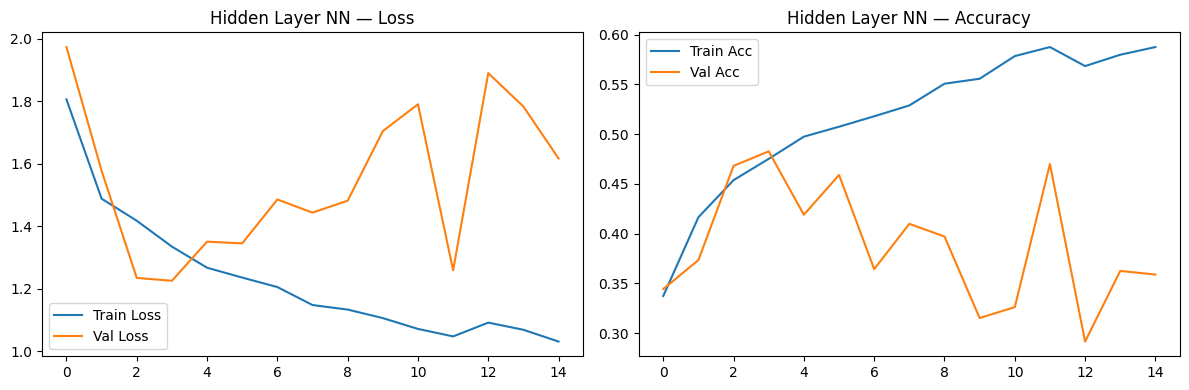

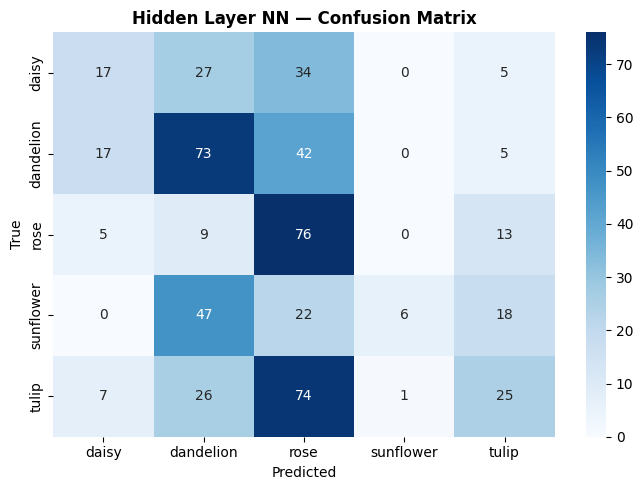


Hidden Layer NN — Classification Report:
              precision    recall  f1-score   support

       daisy       0.37      0.20      0.26        83
   dandelion       0.40      0.53      0.46       137
        rose       0.31      0.74      0.43       103
   sunflower       0.86      0.06      0.12        93
       tulip       0.38      0.19      0.25       133

    accuracy                           0.36       549
   macro avg       0.46      0.35      0.31       549
weighted avg       0.45      0.36      0.32       549



In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║   MODEL 2 — NN WITH HIDDEN LAYERS  (+W&B LOGGING)       ║
# ║   Input: 64x64  |  2 hidden Dense layers                ║
# ╚══════════════════════════════════════════════════════════╝
"""
We add two hidden Dense layers with ReLU activations, Dropout for
regularisation, and BatchNormalization for training stability.
Hidden units are kept at 256/128 (not 512/256) because at 64x64
input, this is sufficient capacity without wasting memory.
This run is logged to Weights & Biases to demonstrate experiment
tracking — a standard practice in modern ML research.
"""

# ── W&B Login ─────────────────────────────────────────────
from google.colab import userdata
WANDB_API_KEY = userdata.get("WANDB_API_KEY")
wandb.login(key=WANDB_API_KEY)

# ── Single W&B run ────────────────────────────────────────
wandb.init(
    project="flower-classification",
    name="hidden-layer-nn",
    config={
        "model":          "Hidden Layer NN",
        "hidden_units_1": 256,
        "hidden_units_2": 128,
        "dropout_1":      0.4,
        "dropout_2":      0.3,
        "epochs":         15,
        "batch_size":     BATCH_SIZE,
        "img_size":       "64x64",
        "optimizer":      "adam",
        "learning_rate":  0.001,
    }
)

hidden_model = keras.Sequential([
    keras.Input(shape=(IMG_HEIGHT_SMALL, IMG_WIDTH_SMALL, IMG_CHANNELS)),
    layers.Flatten(),                               # 12,288 neurons
    layers.Dense(256, activation="relu"),           # safe size for GPU
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
], name="Hidden_Layer_NN")

hidden_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
hidden_model.summary()

history_hidden = hidden_model.fit(
    train_ds_small,
    validation_data=val_ds_small,
    epochs=15,
    callbacks=[WandbMetricsLogger()],
    verbose=1
)
wandb.finish()

plot_history(history_hidden, "Hidden Layer NN")
evaluate_model(hidden_model, val_ds_small, CLASS_NAMES, "Hidden Layer NN")

RESULTS["2. Hidden Layer NN"] = max(history_hidden.history["val_accuracy"])


In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║   MODEL 3 — IMPROVED NN  (BAYESIAN SWEEP + BEST CONFIG) ║
# ╚══════════════════════════════════════════════════════════╝

# ── IMPORTANT: Clear GPU memory before starting sweep ─────
import keras.backend as K
K.clear_session()
import gc
gc.collect()

sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "hidden_units_1": {"values": [64, 128, 256]},   # max 256, not 512
        "hidden_units_2": {"values": [32, 64, 128]},    # max 128, not 256
        "dropout_1":      {"min": 0.2, "max": 0.5},
        "dropout_2":      {"min": 0.1, "max": 0.4},
        "learning_rate":  {"min": 0.00005, "max": 0.005},
        "epochs":         {"values": [10, 15]},          # removed 20 to save time
    }
}

def sweep_train():
    # Clear session at the START of every single sweep run
    K.clear_session()
    gc.collect()

    wandb.init(project="flower-classification")
    cfg = wandb.config

    # Rebuild datasets inside the function — previous session is cleared
    train_data = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR, validation_split=0.2, subset="training",
        seed=42, image_size=(IMG_HEIGHT_SMALL, IMG_WIDTH_SMALL),
        batch_size=16          # smaller batch = less GPU memory per step
    )
    val_data = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR, validation_split=0.2, subset="validation",
        seed=42, image_size=(IMG_HEIGHT_SMALL, IMG_WIDTH_SMALL),
        batch_size=16
    )
    norm = layers.Rescaling(1./255)
    train_data = train_data.map(lambda x, y: (norm(x), y)).prefetch(AUTOTUNE)
    val_data   = val_data.map(lambda x, y: (norm(x), y)).prefetch(AUTOTUNE)

    sweep_model = keras.Sequential([
        keras.Input(shape=(IMG_HEIGHT_SMALL, IMG_WIDTH_SMALL, IMG_CHANNELS)),
        layers.Flatten(),
        layers.Dense(cfg.hidden_units_1, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(cfg.dropout_1),
        layers.Dense(cfg.hidden_units_2, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(cfg.dropout_2),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    sweep_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg.learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    sweep_model.fit(
        train_data,
        validation_data=val_data,
        epochs=cfg.epochs,
        callbacks=[WandbMetricsLogger()],
        verbose=0
    )

    # Clean up after each run
    del sweep_model, train_data, val_data
    K.clear_session()
    gc.collect()
    wandb.finish()

sweep_id = wandb.sweep(sweep_config, project="flower-classification")
wandb.agent(sweep_id, function=sweep_train, count=10)

Create sweep with ID: ojw4yqkc
Sweep URL: https://wandb.ai/aaa2633522-bahria-university/flower-classification/sweeps/ojw4yqkc


wandb: Agent Starting Run: cwpvqcl3 with config:
wandb: 	dropout_1: 0.4952911736536724
wandb: 	dropout_2: 0.3110715106311267
wandb: 	epochs: 10
wandb: 	hidden_units_1: 128
wandb: 	hidden_units_2: 32
wandb: 	learning_rate: 0.0026261667191292675
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.


epoch/accuracy,▁▄▅▇▇▇▇█▇▇
epoch/epoch,▁▂▃▃▄▅▆▆▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▃▂▁▁▁▁▁▁
epoch/val_accuracy,▄▇▅█▇▇▇▁▄▇
epoch/val_loss,▇▅▃▁▁▁▂█▃▂
epoch/accuracy,0.44743
epoch/epoch,9
epoch/learning_rate,0.00263
epoch/loss,1.2704
epoch/val_accuracy,0.44444


wandb: Agent Starting Run: mercfqtc with config:
wandb: 	dropout_1: 0.41146823867582166
wandb: 	dropout_2: 0.3229714582375173
wandb: 	epochs: 10
wandb: 	hidden_units_1: 128
wandb: 	hidden_units_2: 64
wandb: 	learning_rate: 0.004010705908566732
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


...

Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.


epoch/accuracy,▁▄▅▆▅▇▇▇▇█▇▇▆▇█
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▃▂▂▂▂▁▁▁▁▂▂▂▁
epoch/val_accuracy,▃█▇▃█▆▆▄▂▁▅▄▃▆▁
epoch/val_loss,▄▁▁▃▁▂▂▄█▅▃▃▃▂▄
epoch/accuracy,0.50205
epoch/epoch,14
epoch/learning_rate,0.00483
epoch/loss,1.20377
epoch/val_accuracy,0.2714


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: ccavpuxf with config:
wandb: 	dropout_1: 0.3656249266597232
wandb: 	dropout_2: 0.2920748640517572
wandb: 	epochs: 10
wandb: 	hidden_units_1: 256
wandb: 	hidden_units_2: 128
wandb: 	learning_rate: 0.003108732264128361
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.


epoch/accuracy,▁▃▅▅▇▇▇▇▇█
epoch/epoch,▁▂▃▃▄▅▆▆▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▃▃▂▂▂▂▂▁
epoch/val_accuracy,▁▅▄▅▅█▃▂▁▄
epoch/val_loss,█▂▂▂▂▁▃▄▇▄
epoch/accuracy,0.52162
epoch/epoch,9
epoch/learning_rate,0.00311
epoch/loss,1.1529
epoch/val_accuracy,0.39709


In [6]:
# ── Retrain with Best Config (update from W&B dashboard) ──
BEST_CONFIG = {
    "hidden_units_1": 256,   # update from your W&B dashboard
    "hidden_units_2": 128,   # update from your W&B dashboard
    "dropout_1":      0.35,
    "dropout_2":      0.25,
    "learning_rate":  0.0005,
    "epochs":         15,
}

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,792 (16.70 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)


── Phase 1: Feature Extraction ──
Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 70s 584ms/step - accuracy: 0.8252 - loss: 0.4673 - val_accuracy: 0.9199 - val_loss: 0.2490
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.9454 - loss: 0.1743 - val_accuracy: 0.9290 - val_loss: 0.2090
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9686 - loss: 0.1054 - val_accuracy: 0.9362 - val_loss: 0.1917
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.9782 - loss: 0.0710 - val_accuracy: 0.9381 - val_loss: 0.2074
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.9859 - loss: 0.0544 - val_accuracy: 0.9326 - val_loss: 0.2269
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.9914 - loss: 0.0359 - val_accuracy: 0.9417 - val_loss: 0.2090
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9918 - loss: 0.0343 - val_accuracy: 0.9417 - val_loss: 0.2285
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.9909 - lo

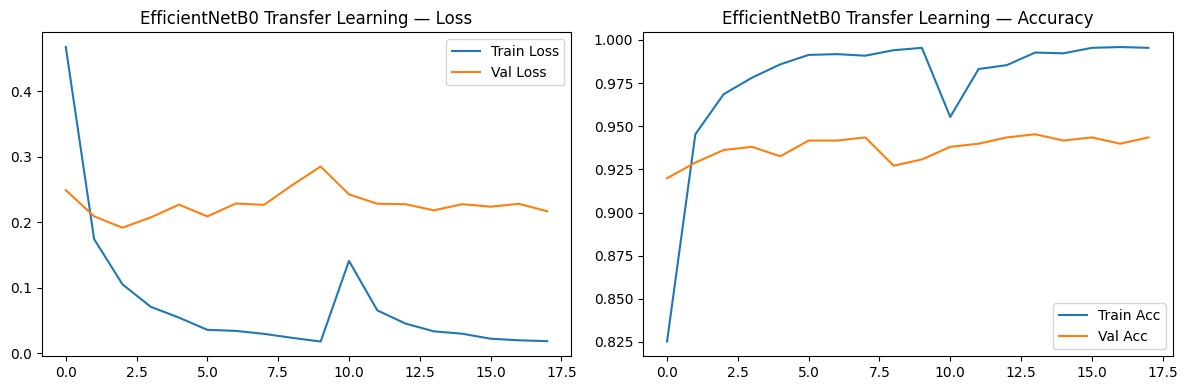

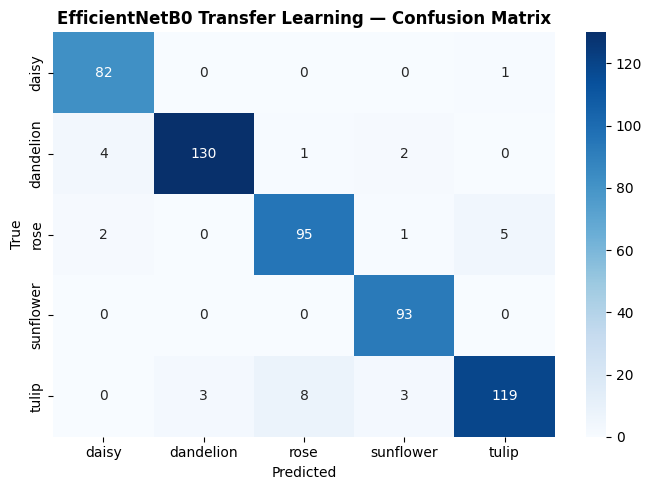


EfficientNetB0 Transfer Learning — Classification Report:
              precision    recall  f1-score   support

       daisy       0.93      0.99      0.96        83
   dandelion       0.98      0.95      0.96       137
        rose       0.91      0.92      0.92       103
   sunflower       0.94      1.00      0.97        93
       tulip       0.95      0.89      0.92       133

    accuracy                           0.95       549
   macro avg       0.94      0.95      0.95       549
weighted avg       0.95      0.95      0.95       549



In [7]:
# ╔══════════════════════════════════════════════════════════╗
# ║   MODEL 4 — TRANSFER LEARNING  (EfficientNetB0)         ║
# ║   Input: 224x224 raw  |  Two-phase fine-tuning          ║
# ╚══════════════════════════════════════════════════════════╝
"""
EfficientNetB0 is pretrained on ImageNet (1.2M images, 1000 classes).
CNN feature extraction means 224x224 images work fine — no OOM.
Phase 1: Freeze entire base, train only the new top layers.
Phase 2: Unfreeze top 30 layers, fine-tune at a lower LR (1e-4).

Why EfficientNetB0?
  • Best accuracy-per-parameter ratio among CNNs
  • Compound scaling balances depth, width, and resolution
  • Has built-in preprocessing — no manual rescaling needed
  • Standard choice in contemporary research
"""

# ── Phase 1: Feature Extraction (frozen base) ────────────
base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
# EfficientNetB0 has built-in preprocessing — pass raw [0,255] images
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

tl_model = keras.Model(inputs, outputs, name="EfficientNetB0_TL")
tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
tl_model.summary()

print("\n── Phase 1: Feature Extraction ──")
history_tl_p1 = tl_model.fit(
    train_ds_raw, validation_data=val_ds_raw, epochs=10, verbose=1
)

# ── Phase 2: Fine-tuning (unfreeze top 30 layers) ─────────
print("\n── Phase 2: Fine-tuning top layers ──")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),   # lower LR for fine-tuning
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history_tl_p2 = tl_model.fit(
    train_ds_raw,
    validation_data=val_ds_raw,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=4, restore_best_weights=True)],
    verbose=1
)

plot_history(merge_histories(history_tl_p1, history_tl_p2),
             "EfficientNetB0 Transfer Learning")
evaluate_model(tl_model, val_ds_raw, CLASS_NAMES, "EfficientNetB0 Transfer Learning")

RESULTS["4. EfficientNetB0 TL"] = max(history_tl_p2.history["val_accuracy"])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,769,925 (178.41 MB)

 Trainable params: 46,768,709 (178.41 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 28s 226ms/step - accuracy: 0.4602 - loss: 1.7584 - val_accuracy: 0.1694 - val_loss: 1.6324
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.5494 - loss: 1.4105 - val_accuracy: 0.2495 - val_loss: 1.9601
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.5808 - loss: 1.2084 - val_accuracy: 0.2495 - val_loss: 3.0811
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.6477 - loss: 0.9975 - val_accuracy: 0.2514 - val_loss: 2.3092
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.7164 - loss: 0.7717 - val_accuracy: 0.3406 - val_loss: 2.4407
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.7410 - loss: 0.7077 - val_accuracy: 0.3169 - val_loss: 1.7749
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.7770 - loss: 0.6020 - val_accuracy: 0.5046 - val_loss: 1.2459
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.8339 - loss: 0.4503 - val_accuracy: 0.6066 -

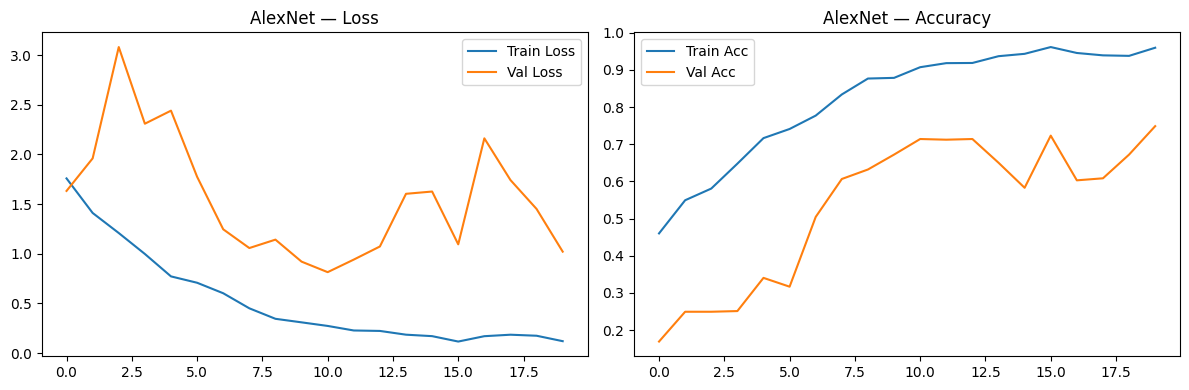

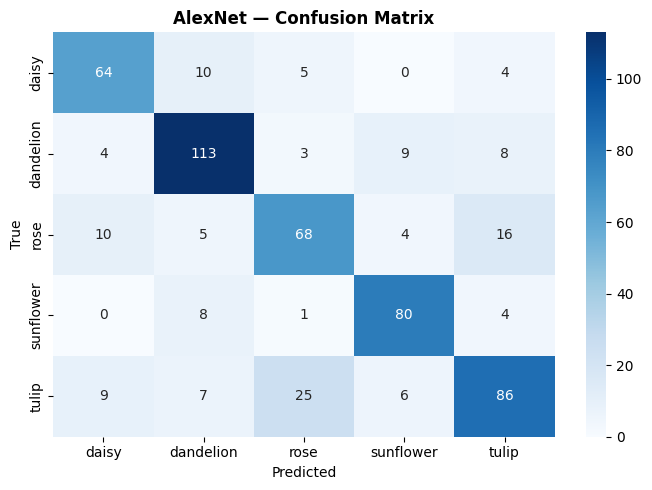


AlexNet — Classification Report:
              precision    recall  f1-score   support

       daisy       0.74      0.77      0.75        83
   dandelion       0.79      0.82      0.81       137
        rose       0.67      0.66      0.66       103
   sunflower       0.81      0.86      0.83        93
       tulip       0.73      0.65      0.69       133

    accuracy                           0.75       549
   macro avg       0.75      0.75      0.75       549
weighted avg       0.75      0.75      0.75       549



In [8]:
# ╔══════════════════════════════════════════════════════════╗
# ║   MODEL 5 — ALEXNET                                     ║
# ║   Input: 224x224 normalised  |  Custom implementation   ║
# ╚══════════════════════════════════════════════════════════╝
"""
AlexNet (Krizhevsky et al., 2012) won ImageNet 2012 and kickstarted
the deep learning era. 5 conv layers + 3 FC layers, ReLU + Dropout.
CNNs are safe at 224x224 — convolutions don't expand memory like
a flatten operation does, so no OOM risk here.
Adapted for 5 output classes with BatchNorm added for stability.
"""

alexnet_model = models.Sequential([
    layers.Conv2D(96, (11,11), strides=(4,4), activation="relu",
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    layers.MaxPooling2D((3,3), strides=(2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(256, (5,5), padding="same", activation="relu"),
    layers.MaxPooling2D((3,3), strides=(2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(384, (3,3), padding="same", activation="relu"),
    layers.Conv2D(384, (3,3), padding="same", activation="relu"),
    layers.Conv2D(256, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((3,3), strides=(2,2)),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(4096, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4096, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
], name="AlexNet")

alexnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
alexnet_model.summary()

history_alexnet = alexnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True)],
    verbose=1
)
plot_history(history_alexnet, "AlexNet")
evaluate_model(alexnet_model, val_ds, CLASS_NAMES, "AlexNet")

RESULTS["5. AlexNet"] = max(history_alexnet.history["val_accuracy"])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 512)       │    262,656 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 512)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    131,328 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 5)         │      1,285 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,109,957 (57.64 MB)

 Trainable params: 395,269 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


── VGG16 Phase 1: Feature Extraction ──
Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 53s 533ms/step - accuracy: 0.6768 - loss: 1.4414 - val_accuracy: 0.8452 - val_loss: 0.4192
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 17s 243ms/step - accuracy: 0.8166 - loss: 0.5599 - val_accuracy: 0.8725 - val_loss: 0.4038
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 233ms/step - accuracy: 0.8603 - loss: 0.4093 - val_accuracy: 0.8780 - val_loss: 0.3411
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 17s 243ms/step - accuracy: 0.8839 - loss: 0.3212 - val_accuracy: 0.8944 - val_loss: 0.3176
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 17s 244ms/step - accuracy: 0.9085 - loss: 0.2710 - val_accuracy: 0.8925 - val_loss: 0.3010
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 17s 240ms/step - accuracy: 0.9208 - loss: 0.2129 - val_accuracy: 0.8944 - val_loss: 0.2932
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 20s 235ms/step - accuracy: 0.9354 - loss: 0.1843 - val_accuracy: 0.8980 - val_loss: 0.3320
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 17s 248ms/step - a

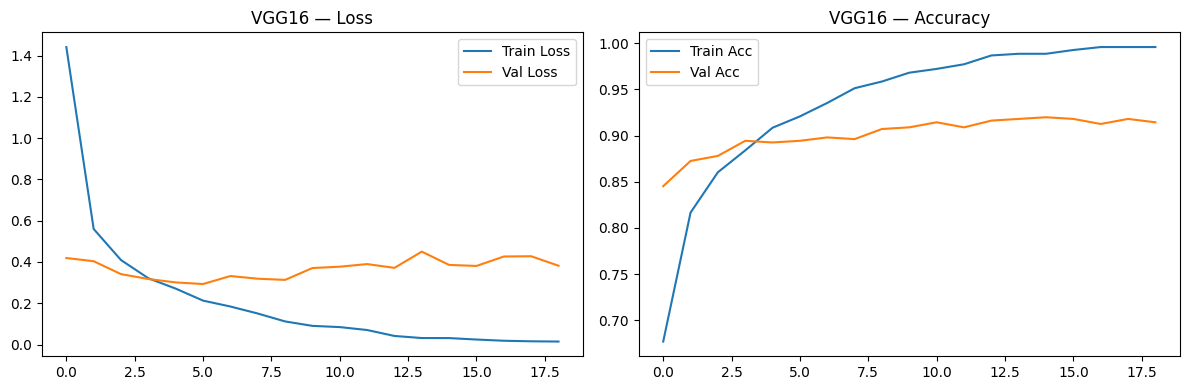

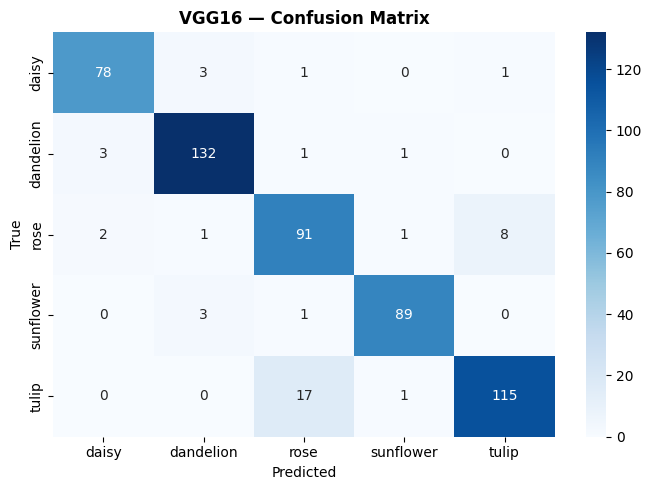


VGG16 — Classification Report:
              precision    recall  f1-score   support

       daisy       0.94      0.94      0.94        83
   dandelion       0.95      0.96      0.96       137
        rose       0.82      0.88      0.85       103
   sunflower       0.97      0.96      0.96        93
       tulip       0.93      0.86      0.89       133

    accuracy                           0.92       549
   macro avg       0.92      0.92      0.92       549
weighted avg       0.92      0.92      0.92       549



In [9]:
# ╔══════════════════════════════════════════════════════════╗
# ║   MODEL 6 — VGG16                                       ║
# ║   Input: 224x224 raw  |  Two-phase fine-tuning          ║
# ╚══════════════════════════════════════════════════════════╝
"""
VGG16 (Simonyan & Zisserman, 2014) uses very deep networks with
small 3×3 convolution filters — 13 conv layers + 3 FC layers.
We use Keras's pretrained VGG16 with ImageNet weights and replace
the top layers for our 5-class problem.
Phase 1: Freeze base, train new head.
Phase 2: Unfreeze only block5 (last conv block) for fine-tuning.
VGG16 has its own preprocess_input that handles [0,255] images.
"""

vgg_base = keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
)
vgg_base.trainable = False

inputs_vgg = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
x_vgg = keras.applications.vgg16.preprocess_input(inputs_vgg)
x_vgg = vgg_base(x_vgg, training=False)
x_vgg = layers.GlobalAveragePooling2D()(x_vgg)
x_vgg = layers.Dense(512, activation="relu")(x_vgg)
x_vgg = layers.Dropout(0.4)(x_vgg)
x_vgg = layers.Dense(256, activation="relu")(x_vgg)
x_vgg = layers.Dropout(0.3)(x_vgg)
outputs_vgg = layers.Dense(NUM_CLASSES, activation="softmax")(x_vgg)

vgg_model = keras.Model(inputs_vgg, outputs_vgg, name="VGG16")
# ── Phase 1: Feature Extraction ───────────────────────────
vgg_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
vgg_model.summary()

print("\n── VGG16 Phase 1: Feature Extraction ──")
history_vgg_p1 = vgg_model.fit(
    train_ds_raw, validation_data=val_ds_raw, epochs=10, verbose=1
)

# ── Phase 2: Fine-tune block5 only ────────────────────────
print("\n── VGG16 Phase 2: Fine-tuning block5 ──")
vgg_base.trainable = True
for layer in vgg_base.layers:
    layer.trainable = layer.name.startswith("block5")

vgg_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history_vgg_p2 = vgg_model.fit(
    train_ds_raw,
    validation_data=val_ds_raw,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=4, restore_best_weights=True)],
    verbose=1
)

plot_history(merge_histories(history_vgg_p1, history_vgg_p2), "VGG16")
evaluate_model(vgg_model, val_ds_raw, CLASS_NAMES, "VGG16")

RESULTS["6. VGG16"] = max(history_vgg_p2.history["val_accuracy"])



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ input_layer_6[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ input_layer_6[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ input_layer_6[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 512)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 256)       │    131,328 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 5)         │      1,285 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,769,413 (94.49 MB)

 Trainable params: 1,181,701 (4.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


── ResNet50 Phase 1: Feature Extraction ──
Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 39s 321ms/step - accuracy: 0.7460 - loss: 0.7170 - val_accuracy: 0.8834 - val_loss: 0.3067
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.8880 - loss: 0.3143 - val_accuracy: 0.9253 - val_loss: 0.2473
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.9103 - loss: 0.2395 - val_accuracy: 0.9271 - val_loss: 0.2203
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.9335 - loss: 0.1861 - val_accuracy: 0.9089 - val_loss: 0.2893
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.9531 - loss: 0.1377 - val_accuracy: 0.9180 - val_loss: 0.2660
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.9558 - loss: 0.1256 - val_accuracy: 0.9107 - val_loss: 0.3394
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.9695 - loss: 0.0827 - val_accuracy: 0.9180 - val_loss: 0.3293
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - acc

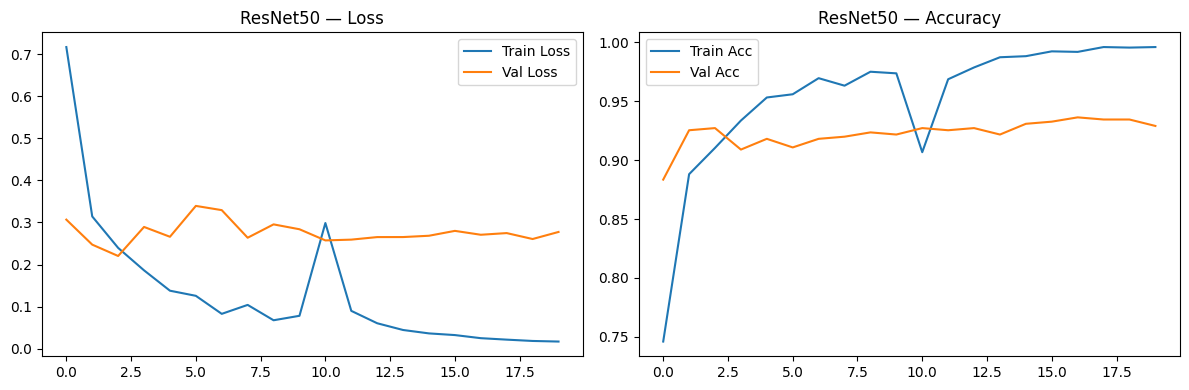

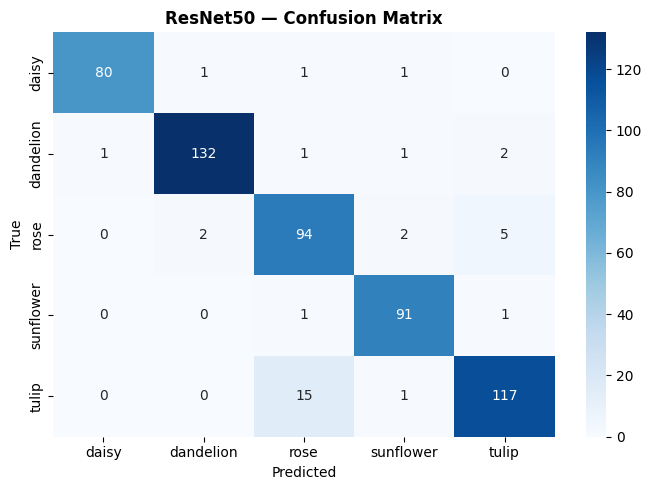


ResNet50 — Classification Report:
              precision    recall  f1-score   support

       daisy       0.99      0.96      0.98        83
   dandelion       0.98      0.96      0.97       137
        rose       0.84      0.91      0.87       103
   sunflower       0.95      0.98      0.96        93
       tulip       0.94      0.88      0.91       133

    accuracy                           0.94       549
   macro avg       0.94      0.94      0.94       549
weighted avg       0.94      0.94      0.94       549


══════════════════════════════════════════════════════════
   FINAL MODEL COMPARISON — Validation Accuracy
══════════════════════════════════════════════════════════
Model                                      Val Accuracy
──────────────────────────────────────────────────────────
1. Linear NN                                    0.4645  █████████████
2. Hidden Layer NN                              0.4827  ██████████████
4. EfficientNetB0 TL                            0.945

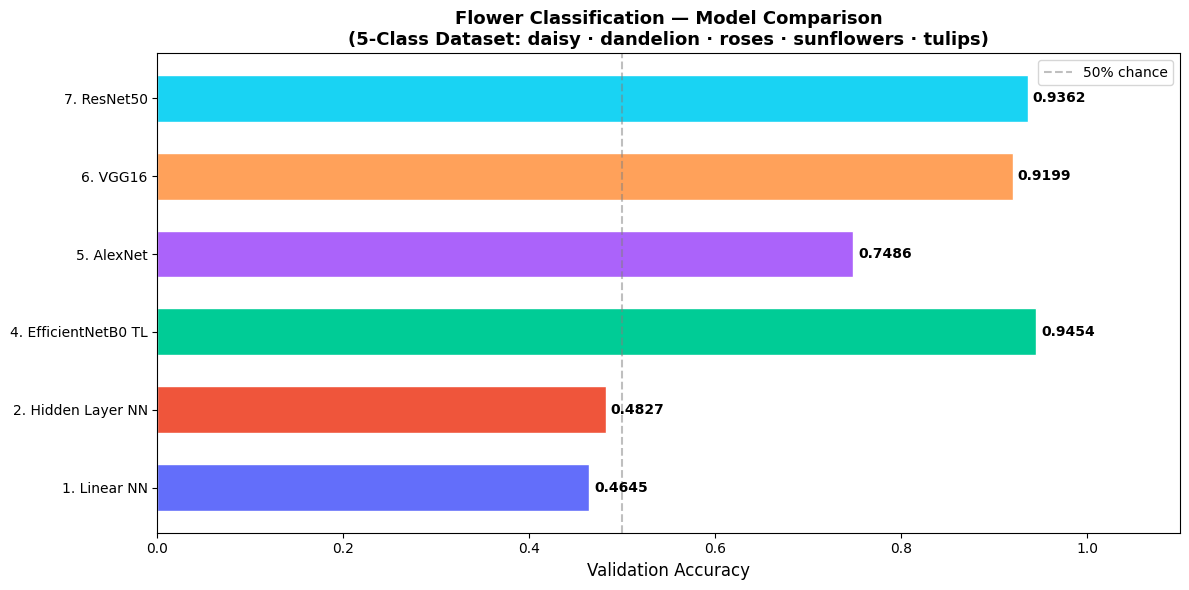

In [10]:
# ║   MODEL 7 — RESNET50                                    ║
# ║   Input: 224x224 raw  |  Two-phase fine-tuning          ║
# ╚══════════════════════════════════════════════════════════╝
"""
ResNet50 (He et al., 2015) introduced residual skip connections,
solving the vanishing gradient problem in very deep networks.
50 layers with identity shortcuts allow gradients to flow directly
through the network. Remains one of the most cited CV architectures.
Phase 2 fine-tunes only conv5 block (last residual block).
"""

resnet_base = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
)
resnet_base.trainable = False

inputs_res = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
x_res = keras.applications.resnet50.preprocess_input(inputs_res)
x_res = resnet_base(x_res, training=False)
x_res = layers.GlobalAveragePooling2D()(x_res)
x_res = layers.Dense(512, activation="relu")(x_res)
x_res = layers.Dropout(0.4)(x_res)
x_res = layers.Dense(256, activation="relu")(x_res)
x_res = layers.Dropout(0.3)(x_res)
outputs_res = layers.Dense(NUM_CLASSES, activation="softmax")(x_res)

resnet_model = keras.Model(inputs_res, outputs_res, name="ResNet50")

# ── Phase 1: Feature Extraction ───────────────────────────
resnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
resnet_model.summary()

print("\n── ResNet50 Phase 1: Feature Extraction ──")
history_res_p1 = resnet_model.fit(
    train_ds_raw, validation_data=val_ds_raw, epochs=10, verbose=1
)

# ── Phase 2: Fine-tune conv5 block ────────────────────────
print("\n── ResNet50 Phase 2: Fine-tuning conv5 ──")
resnet_base.trainable = True
for layer in resnet_base.layers:
    layer.trainable = ("conv5" in layer.name)

resnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history_res_p2 = resnet_model.fit(
    train_ds_raw,
    validation_data=val_ds_raw,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=4, restore_best_weights=True)],
    verbose=1
)

plot_history(merge_histories(history_res_p1, history_res_p2), "ResNet50")
evaluate_model(resnet_model, val_ds_raw, CLASS_NAMES, "ResNet50")

RESULTS["7. ResNet50"] = max(history_res_p2.history["val_accuracy"])


# ╔══════════════════════════════════════════════════════════╗
# ║   SECTION 8 — FINAL COMPARISON TABLE & BAR CHART        ║
# ╚══════════════════════════════════════════════════════════╝

print("\n" + "═"*58)
print("   FINAL MODEL COMPARISON — Validation Accuracy")
print("═"*58)
print(f"{'Model':<42} {'Val Accuracy':>12}")
print("─"*58)
for name, acc in RESULTS.items():
    bar = "█" * int(acc * 30)
    print(f"{name:<42} {acc:>11.4f}  {bar}")
print("═"*58)

best_model = max(RESULTS, key=RESULTS.get)
print(f"\n🏆 Best Model: {best_model}  ({RESULTS[best_model]:.4f})")

# ── Bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#636EFA","#EF553B","#00CC96","#AB63FA",
          "#FFA15A","#19D3F3","#FF6692"]

bars = ax.barh(list(RESULTS.keys()), list(RESULTS.values()),
               color=colors[:len(RESULTS)], edgecolor="white", height=0.6)

for bar, val in zip(bars, RESULTS.values()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10, fontweight="bold")

ax.set_xlim(0, 1.1)
ax.set_xlabel("Validation Accuracy", fontsize=12)
ax.set_title("Flower Classification — Model Comparison\n(5-Class Dataset: daisy · dandelion · roses · sunflowers · tulips)",
             fontsize=13, fontweight="bold")
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="50% chance")
ax.legend()
plt.tight_layout()
plt.show()
